# Project 2 — Оценка пространственной доступности

**Курс:** Пространственный анализ на Python (HSE, 2026)
**Город:** Москва · **Район:** Хамовники
**Объекты:** школы (`amenity=school`) и детские сады (`amenity=kindergarten`)

## Цель
Оцениваю пешеходную доступность двух категорий объектов для жителей района: строю зоны
доступности, прикидываю население жилых домов по жилой площади и считаю, какая доля
жителей оказывается внутри и вне зон для каждой категории.

## Ход работы
1. Загружаю границу района, объекты двух категорий и жилые здания
2. Смотрю, что в данных
3. Готовлю слои: объекты → точки, здания → жилые полигоны
4. Перевожу всё в метрическую проекцию (UTM)
5. Оцениваю население по жилой площади
6. Строю зоны пешеходной доступности
7. Считаю население внутри и вне зон
8. Рисую карты
9. Делаю выводы

## 0. Библиотеки

Подключаю всё, что использую дальше.

In [1]:
# pip install osmnx geopandas matplotlib mapclassify shapely

In [2]:
import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("osmnx    :", ox.__version__)
print("geopandas:", gpd.__version__)

# Единые настройки графиков
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

osmnx    : 2.0.7
geopandas: 1.0.1


### Параметры

Здесь задаю район, две категории объектов с радиусами пешей доступности и допущения,
по которым оцениваю население. Радиусы беру по нормам: школа — 500 м, детский сад — 300 м.

In [3]:
PLACE = "Khamovniki District, Moscow, Russia"

# Две категории объектов: имя -> (OSM-теги, радиус пешей доступности в метрах, цвет)
CATEGORIES = {
    "Школы":       {"tags": {"amenity": "school"},       "radius_m": 500, "color": "#1f77b4"},
    "Детские сады": {"tags": {"amenity": "kindergarten"}, "radius_m": 300, "color": "#d62728"},
}

# --- параметры оценки населения по жилой площади ---
# Типы зданий OSM, считающиеся жилыми
RESIDENTIAL_TYPES = {
    "residential", "apartments", "house", "detached",
    "dormitory", "terrace", "semidetached_house",
}
DEFAULT_LEVELS          = 5     # этажность по умолчанию, если тег building:levels отсутствует
LIVING_AREA_EFFICIENCY  = 0.70  # доля жилой (полезной) площади от общей площади этажей
AREA_PER_PERSON_M2      = 30.0  # обеспеченность жилой площадью, м² на человека

## 1. Загрузка данных из OpenStreetMap

Беру границу района, объекты обеих категорий и все здания — по зданиям дальше оцениваю
население.

In [4]:
# Граница района (полигон)
boundary = ox.geocode_to_gdf(PLACE)
print("Граница загружена:", boundary.shape)
boundary[["display_name", "geometry"]].head()

Граница загружена: (1, 17)


,display_name,geometry
0,"Khamovniki District, Moscow, Central Federal D...","POLYGON ((37.54108 55.72013, 37.54189 55.71759..."


In [5]:
# Объекты обеих категорий
category_raw = {}
for name, cfg in CATEGORIES.items():
    gdf = ox.features_from_place(PLACE, tags=cfg["tags"])
    category_raw[name] = gdf
    print(f"{name:14s}: {len(gdf):4d} объектов (сырые)")

Школы         :   28 объектов (сырые)
Детские сады  :   40 объектов (сырые)


In [6]:
# Все здания района (для оценки населения)
buildings_raw = ox.features_from_place(PLACE, tags={"building": True})
print("Здания (сырые):", buildings_raw.shape)

Здания (сырые): (2837, 228)


## 2. Разведочный анализ

Смотрю на размер слоёв, типы геометрии и ключевые атрибуты.

In [7]:
for name, gdf in category_raw.items():
    print(f"=== {name} ===")
    print("Объектов:", len(gdf))
    print("Типы геометрии:", dict(gdf.geom_type.value_counts()))
    print()

=== Школы ===
Объектов: 28
Типы геометрии: {'Polygon': 25, 'Point': 3}

=== Детские сады ===
Объектов: 40
Типы геометрии: {'Point': 20, 'Polygon': 20}



In [8]:
print("=== ЗДАНИЯ ===")
print("Объектов :", len(buildings_raw))
print("Типы геометрии:", dict(buildings_raw.geom_type.value_counts()))
print("\nЧастые значения тега building:")
print(buildings_raw["building"].value_counts().head(12))
have_levels = buildings_raw["building:levels"].notna().mean() if "building:levels" in buildings_raw else 0
print(f"\nДоля зданий с указанной этажностью (building:levels): {have_levels:.1%}")

=== ЗДАНИЯ ===
Объектов : 2837
Типы геометрии: {'Polygon': 2805, 'Point': 22, 'MultiPolygon': 10}

Частые значения тега building:
building
yes             1067
apartments       614
office           301
service          212
commercial       118
retail            41
hospital          41
government        34
construction      33
garages           30
roof              30
school            28
Name: count, dtype: int64

Доля зданий с указанной этажностью (building:levels): 78.2%


## 3. Обработка данных

- Объекты категорий привожу к точкам — вокруг них строю зоны доступности.
- Здания оставляю полигональными (по ним считается площадь) и отбираю только жилые
  типы из `RESIDENTIAL_TYPES`.

In [9]:
def to_points(gdf):
    """Приводит объекты к точкам: точки оставляем, у полигонов берём центроид."""
    g = gdf.copy()
    g = g[~g.geometry.is_empty & g.geometry.notna()]
    g["geometry"] = g.geometry.representative_point()
    keep = [c for c in ["name", "amenity"] if c in g.columns]
    return g[keep + ["geometry"]].reset_index(drop=True)

category_pts = {name: to_points(gdf) for name, gdf in category_raw.items()}
for name, g in category_pts.items():
    print(f"{name:14s}: {len(g):4d} точек")

Школы         :   28 точек
Детские сады  :   40 точек


In [10]:
def keep_polygons(gdf, cols):
    poly = gdf[gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    cols = [c for c in cols if c in poly.columns]
    return poly[cols + ["geometry"]]

build_cols = ["building", "building:levels", "name"]
buildings = keep_polygons(buildings_raw, build_cols)

# Только жилые здания
residential = buildings[buildings["building"].isin(RESIDENTIAL_TYPES)].copy()
print("Всего зданий-полигонов :", len(buildings))
print("Жилых зданий           :", len(residential))
residential["building"].value_counts()

Всего зданий-полигонов : 2815
Жилых зданий           : 641


building
apartments     614
house           20
dormitory        5
residential      2
Name: count, dtype: int64

## 4. Перепроецирование в метрическую систему (UTM)

Координаты в градусах (`EPSG:4326`) — в них нельзя считать ни площади, ни расстояния для
буферов. Перевожу всё в UTM-зону (для Москвы 37N) и обрезаю жилые здания по границе
района, чтобы население считалось только внутри.

In [11]:
utm_crs = boundary.estimate_utm_crs()
print("Целевая система координат:", utm_crs)

boundary_m    = boundary.to_crs(utm_crs)
residential_m = residential.to_crs(utm_crs)
category_m    = {name: g.to_crs(utm_crs) for name, g in category_pts.items()}

# Жилые здания — строго внутри района
residential_m = gpd.clip(residential_m, boundary_m).reset_index(drop=True)
print("Жилых зданий внутри района:", len(residential_m))

Целевая система координат: EPSG:32637
Жилых зданий внутри района: 641


## 5. Оценка населения по жилой площади

Население дома прикидываю по цепочке:

```
площадь застройки = площадь полигона здания
площадь этажей    = площадь застройки × этажность
жилая площадь     = площадь этажей × LIVING_AREA_EFFICIENCY
население         = жилая площадь / AREA_PER_PERSON_M2
```

Этажность беру из тега `building:levels`, а где его нет — подставляю `DEFAULT_LEVELS`.

In [12]:
def parse_levels(val):
    """Аккуратно парсит building:levels (бывают строки, диапазоны, мусор)."""
    if pd.isna(val):
        return np.nan
    s = str(val).split(";")[0].split("-")[0].strip().replace(",", ".")
    try:
        n = float(s)
        return n if 0 < n < 200 else np.nan
    except ValueError:
        return np.nan

r = residential_m.copy()
r["levels"]    = r["building:levels"].apply(parse_levels).fillna(DEFAULT_LEVELS)
r["footprint"] = r.area
r["floor_area"] = r["footprint"] * r["levels"]
r["living_area"] = r["floor_area"] * LIVING_AREA_EFFICIENCY
r["population"]  = r["living_area"] / AREA_PER_PERSON_M2

residential_m = r
total_pop = r["population"].sum()
print(f"Жилых зданий          : {len(r)}")
print(f"Суммарная жилая площадь: {r['living_area'].sum()/1e3:,.1f} тыс. м²")
print(f"Оценка населения района: {total_pop:,.0f} чел.")
print(f"Средняя этажность      : {r['levels'].mean():.1f}")

Жилых зданий          : 641
Суммарная жилая площадь: 3,574.8 тыс. м²
Оценка населения района: 119,159 чел.
Средняя этажность      : 6.8


## 6. Зоны пешеходной доступности

Зону доступности категории строю как объединение буферов вокруг всех её объектов с
нормативным радиусом — это область, из которой до ближайшего объекта можно дойти пешком
в пределах нормы.

In [13]:
zones = {}
for name, pts in category_m.items():
    radius = CATEGORIES[name]["radius_m"]
    buf = pts.buffer(radius).union_all()
    # Ограничиваем зону границей района — для корректной визуализации и площадей
    buf = buf.intersection(boundary_m.union_all())
    zones[name] = buf
    area_km2 = buf.area / 1e6
    cover = buf.area / boundary_m.area.sum() * 100
    print(f"{name:14s}: радиус {radius} м, площадь зоны {area_km2:5.2f} км² ({cover:4.1f}% района)")

Школы         : радиус 500 м, площадь зоны  7.67 км² (76.2% района)
Детские сады  : радиус 300 м, площадь зоны  4.66 км² (46.3% района)


## 7. Население внутри и вне зон

Дом считаю обеспеченным, если его точка попадает в зону доступности. Для каждой
категории считаю, сколько жителей внутри зоны, а сколько вне.

In [14]:
results = []
reps = residential_m.geometry.representative_point()

for name, zone in zones.items():
    inside_mask = reps.within(zone)
    residential_m[f"in_{name}"] = inside_mask.values
    pop_in  = residential_m.loc[inside_mask.values, "population"].sum()
    pop_out = total_pop - pop_in
    results.append({
        "Категория": name,
        "Радиус, м": CATEGORIES[name]["radius_m"],
        "Зданий внутри": int(inside_mask.sum()),
        "Зданий вне": int((~inside_mask).sum()),
        "Население внутри": round(pop_in),
        "Население вне": round(pop_out),
        "Доля внутри, %": round(pop_in / total_pop * 100, 1),
        "Доля вне, %": round(pop_out / total_pop * 100, 1),
    })

summary = pd.DataFrame(results)
summary

,Категория,"Радиус, м",Зданий внутри,Зданий вне,Население внутри,Население вне,"Доля внутри, %","Доля вне, %"
0,Школы,500,638,3,117827,1331,98.9,1.1
1,Детские сады,300,432,209,85449,33710,71.7,28.3


## 8. Карты

Для каждой категории рисую карту района: жилые дома в зоне и вне её, сами объекты и
контур зоны доступности.

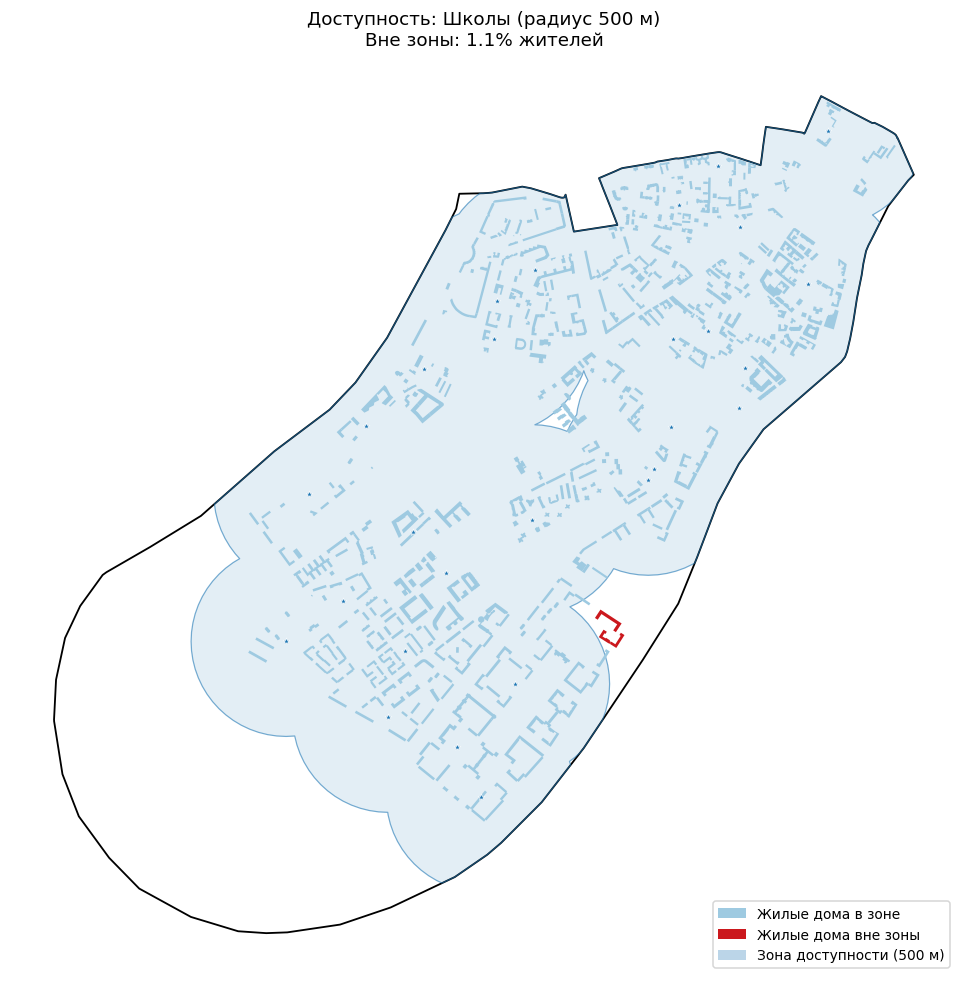

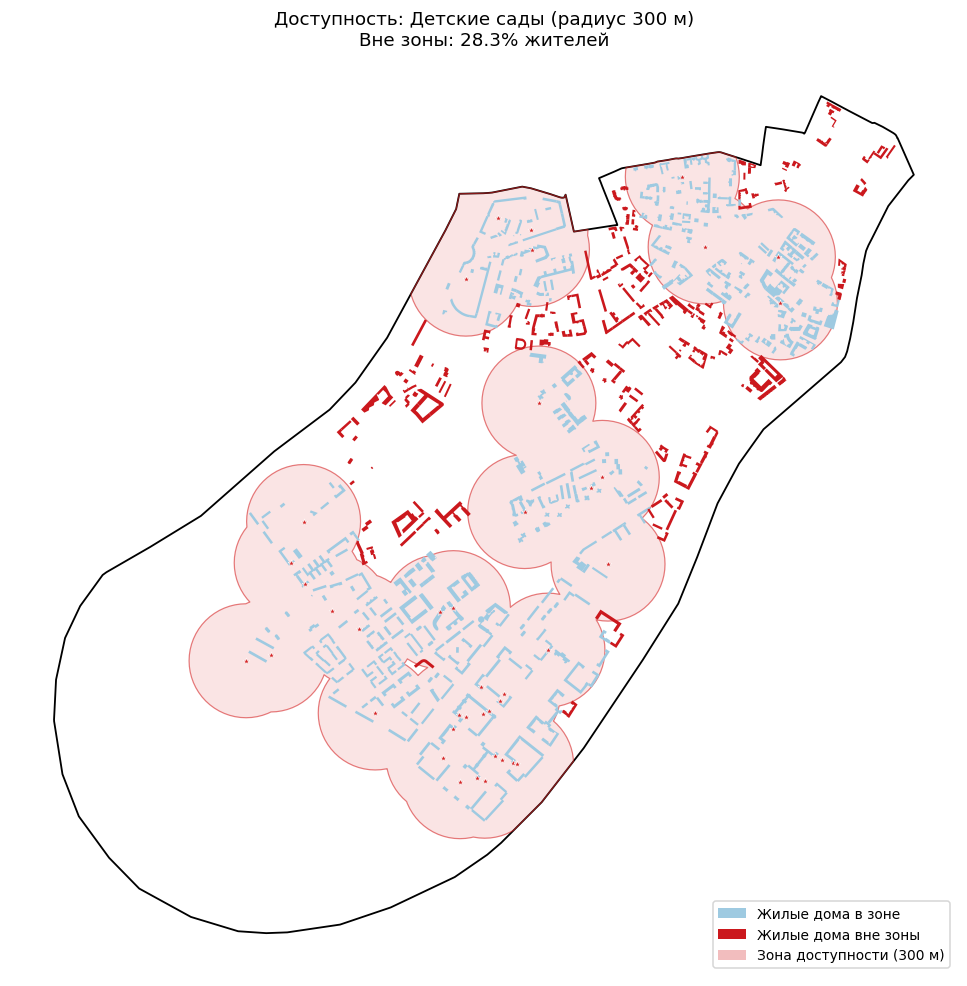

In [15]:
def plot_category(name):
    zone = zones[name]
    color = CATEGORIES[name]["color"]
    radius = CATEGORIES[name]["radius_m"]
    zone_gdf = gpd.GeoSeries([zone], crs=utm_crs)

    fig, ax = plt.subplots(figsize=(9, 9))
    boundary_m.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=1)
    zone_gdf.plot(ax=ax, color=color, alpha=0.12, zorder=2)
    zone_gdf.boundary.plot(ax=ax, color=color, linewidth=0.8, alpha=0.6, zorder=3)

    inside = residential_m[residential_m[f"in_{name}"]]
    outside = residential_m[~residential_m[f"in_{name}"]]
    inside.plot(ax=ax, color="#9ecae1", edgecolor="none", zorder=4)
    outside.plot(ax=ax, color="#cb181d", edgecolor="none", zorder=5)
    category_m[name].plot(ax=ax, color=color, markersize=22,
                          marker="*", edgecolor="white", linewidth=0.4, zorder=6)

    row = summary[summary["Категория"] == name].iloc[0]
    ax.set_title(f"Доступность: {name} (радиус {radius} м)\n"
                 f"Вне зоны: {row['Доля вне, %']}% жителей", fontsize=12)
    ax.set_axis_off()
    legend = [
        Patch(facecolor="#9ecae1", label="Жилые дома в зоне"),
        Patch(facecolor="#cb181d", label="Жилые дома вне зоны"),
        Patch(facecolor=color, alpha=0.3, label=f"Зона доступности ({radius} м)"),
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.show()

for name in CATEGORIES:
    plot_category(name)

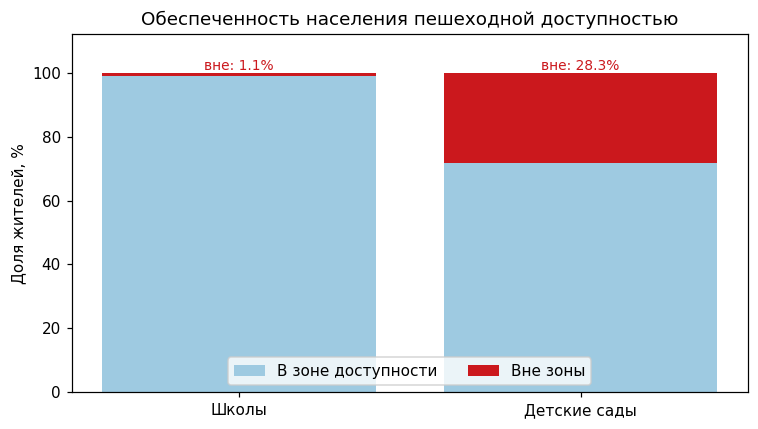

In [16]:
# Сводная диаграмма: доля жителей вне зоны по категориям
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(summary))
ax.bar(x, summary["Доля внутри, %"], label="В зоне доступности", color="#9ecae1")
ax.bar(x, summary["Доля вне, %"], bottom=summary["Доля внутри, %"],
       label="Вне зоны", color="#cb181d")
ax.set_xticks(x)
ax.set_xticklabels(summary["Категория"])
ax.set_ylabel("Доля жителей, %")
ax.set_title("Обеспеченность населения пешеходной доступностью")
for i, v in enumerate(summary["Доля вне, %"]):
    ax.text(i, 101, f"вне: {v}%", ha="center", fontsize=9, color="#cb181d")
ax.legend(loc="lower center", ncol=2)
ax.set_ylim(0, 112)
plt.tight_layout()
plt.show()

## 9. Выводы

In [17]:
print("ИТОГИ ПО РАЙОНУ ХАМОВНИКИ")
print("=" * 48)
print(f"Оценка населения района: {total_pop:,.0f} чел.")
print(f"Жилых зданий учтено    : {len(residential_m)}")
print()
for _, row in summary.iterrows():
    print(f"• {row['Категория']} (радиус {row['Радиус, м']} м):")
    print(f"    в зоне доступности — {row['Доля внутри, %']}% "
          f"(~{row['Население внутри']:,.0f} чел.)")
    print(f"    вне зоны           — {row['Доля вне, %']}% "
          f"(~{row['Население вне']:,.0f} чел., {row['Зданий вне']} домов)")
    print()

ИТОГИ ПО РАЙОНУ ХАМОВНИКИ
Оценка населения района: 119,159 чел.
Жилых зданий учтено    : 641

• Школы (радиус 500 м):
    в зоне доступности — 98.9% (~117,827 чел.)
    вне зоны           — 1.1% (~1,331 чел., 3 домов)

• Детские сады (радиус 300 м):
    в зоне доступности — 71.7% (~85,449 чел.)
    вне зоны           — 28.3% (~33,710 чел., 209 домов)



### Выводы

- По моей оценке в Хамовниках живёт около **119 тыс. человек** (641 жилой дом, средняя
  этажность ~7). Это оценка по жилой площади из OSM, не перепись, но порядок похож на
  реальный.
- **Школы (радиус 500 м)** покрывают район почти целиком: вне зоны остаётся лишь ~**1%**
  жителей (около 1,3 тыс. человек, 3 дома). По школам район обеспечен хорошо.
- **Детские сады (радиус 300 м)** — заметно хуже: вне пешеходной доступности оказывается
  ~**28%** жителей (около 34 тыс. человек, 209 домов). Дело прежде всего в радиусе: 300 м
  покрывают гораздо меньшую площадь, чем 500 м, — даже при том что садов в данных больше,
  чем школ.
- На картах это видно: красные дома вне зон жмутся к краям района — именно туда логично
  добавлять новые детские сады.
- Ограничения: население оценено с допущениями об этажности и норме жилой площади; буфер
  по прямой немного завышает доступность по сравнению с реальными маршрутами (реки, ж/д,
  заборы); результат зависит от полноты OSM. Точнее было бы считать сетевые изохроны и
  брать жилую площадь из фактических данных.